# 4. Efecto de la Diversificación sobre el Riesgo

En las próximas secciones analizaremos como se descompone el riesgo y las medidas que ayudan a evaluar el desempeño. las diapositivas de las sesiones 4 5 y 6 se pueden descargar aquí: [Descargar_diapositivas](4_Modelo_CAPM-SML.pdf)

## ¿Por qué agregar activos reduce el riesgo, pero nunca lo elimina?

Uno de los resultados más importantes de la teoría de portafolios es que **diversificar reduce el riesgo**, pero existe un **límite inferior** que no se puede cruzar sin importar cuántos activos agreguemos.

Esto ocurre porque el riesgo total de un portafolio se descompone en:

$$\sigma^2_p = \underbrace{\text{Riesgo diversificable}}_{\text{Se elimina con } N \to \infty} + \underbrace{\text{Riesgo sistemático}}_{\text{No se puede eliminar}}$$

---

### Modelo teórico

Supongamos un portafolio **equiponderado** ($w_i = 1/N$) con $N$ activos donde:
- Cada activo tiene la **misma varianza**: $\sigma^2$
- Cada par de activos tiene la **misma correlación**: $\rho$

Entonces la varianza del portafolio es:

$$\boxed{\sigma^2_p = \frac{\sigma^2}{N} + \left(1 - \frac{1}{N}\right) \rho \, \sigma^2}$$

Cuando $N \to \infty$:

$$\sigma^2_p \to \rho \, \sigma^2$$

El primer término $\frac{\sigma^2}{N}$ (riesgo idiosincrático) **desaparece**, pero el segundo término $\rho \, \sigma^2$ (riesgo sistemático) **permanece**.

## Paso 1 — Derivación de la fórmula

Partimos de la fórmula general de varianza de un portafolio:

$$\sigma^2_p = \sum_{i=1}^{N} \sum_{j=1}^{N} w_i \, w_j \, \sigma_{ij}$$

Con pesos iguales $w_i = \frac{1}{N}$:

$$\sigma^2_p = \sum_{i=1}^{N} \sum_{j=1}^{N} \frac{1}{N^2} \sigma_{ij}$$

Separamos los términos de la diagonal ($i = j$) y los fuera de la diagonal ($i \neq j$):

$$\sigma^2_p = \frac{1}{N^2} \sum_{i=1}^{N} \sigma^2_i + \frac{1}{N^2} \sum_{i \neq j} \sigma_{ij}$$

Si todos los activos tienen varianza $\sigma^2$ y covarianza $\sigma_{ij} = \rho \sigma^2$ (para $i \neq j$):

- Hay $N$ términos en la diagonal → $\frac{N \sigma^2}{N^2} = \frac{\sigma^2}{N}$
- Hay $N(N-1)$ términos fuera de la diagonal → $\frac{N(N-1) \rho \sigma^2}{N^2} = \left(1 - \frac{1}{N}\right) \rho \sigma^2$

$$\boxed{\sigma^2_p = \frac{\sigma^2}{N} + \left(1 - \frac{1}{N}\right) \rho \, \sigma^2}$$

## Paso 2 — Implementación numérica

Definimos la función de varianza del portafolio y evaluamos para diferentes valores de $N$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ─── Parámetros teóricos ───
sigma = 0.30          # Volatilidad individual de cada activo (30% anual)
rho = 0.25            # Correlación entre cada par de activos

# ─── Fórmula de varianza del portafolio equiponderado ───
def varianza_portafolio(N, sigma, rho):
    """
    Varianza de un portafolio equiponderado con N activos,
    cada uno con varianza sigma² y correlación par-a-par rho.
    """
    var = sigma**2
    return var / N + (1 - 1/N) * rho * var

# ─── Evaluar para N = 1 hasta 100 ───
N_valores = np.arange(1, 101)
var_p = [varianza_portafolio(N, sigma, rho) for N in N_valores]
vol_p = np.sqrt(var_p)  # Desviación estándar (volatilidad)

# Límite asintótico (N → ∞)
var_sistematico = rho * sigma**2
vol_sistematico = np.sqrt(var_sistematico)

print(f"Parámetros del ejemplo:")
print(f"  σ individual     = {sigma:.0%}")
print(f"  ρ (correlación)  = {rho}")
print(f"  σ² individual    = {sigma**2:.4f}")
print(f"")
print(f"Riesgo del portafolio:")
print(f"  N =  1 activo  → σ_p = {np.sqrt(varianza_portafolio(1, sigma, rho)):.2%}")
print(f"  N =  5 activos → σ_p = {np.sqrt(varianza_portafolio(5, sigma, rho)):.2%}")
print(f"  N = 10 activos → σ_p = {np.sqrt(varianza_portafolio(10, sigma, rho)):.2%}")
print(f"  N = 30 activos → σ_p = {np.sqrt(varianza_portafolio(30, sigma, rho)):.2%}")
print(f"  N = 50 activos → σ_p = {np.sqrt(varianza_portafolio(50, sigma, rho)):.2%}")
print(f"  N =100 activos → σ_p = {np.sqrt(varianza_portafolio(100, sigma, rho)):.2%}")
print(f"  N → ∞          → σ_p = {vol_sistematico:.2%}  ← límite (riesgo sistemático)")

Parámetros del ejemplo:
  σ individual     = 30%
  ρ (correlación)  = 0.25
  σ² individual    = 0.0900

Riesgo del portafolio:
  N =  1 activo  → σ_p = 30.00%
  N =  5 activos → σ_p = 18.97%
  N = 10 activos → σ_p = 17.10%
  N = 30 activos → σ_p = 15.73%
  N = 50 activos → σ_p = 15.44%
  N =100 activos → σ_p = 15.22%
  N → ∞          → σ_p = 15.00%  ← límite (riesgo sistemático)


## Paso 3 — Tabla: descomposición del riesgo

Mostremos cómo cada componente del riesgo evoluciona al aumentar $N$:

In [2]:
import pandas as pd

N_tabla = [1, 2, 5, 10, 20, 30, 50, 100]
var_ind = sigma**2

filas = []
for N in N_tabla:
    comp_diversificable = var_ind / N                       # σ²/N
    comp_sistematico = (1 - 1/N) * rho * var_ind            # (1 - 1/N)ρσ²
    var_total = comp_diversificable + comp_sistematico
    vol_total = np.sqrt(var_total)
    reduccion = (1 - vol_total / sigma) * 100               # % reducción vs 1 activo
    filas.append({
        "N activos": N,
        "σ²/N (diversificable)": f"{comp_diversificable:.6f}",
        "(1-1/N)ρσ² (sistemático)": f"{comp_sistematico:.6f}",
        "σ²_p (total)": f"{var_total:.6f}",
        "σ_p (volatilidad)": f"{vol_total:.2%}",
        "Reducción vs 1 activo": f"{reduccion:.1f}%"
    })

tabla = pd.DataFrame(filas)
tabla

,N activos,σ²/N (diversificable),(1-1/N)ρσ² (sistemático),σ²_p (total),σ_p (volatilidad),Reducción vs 1 activo
0,1,0.090000,0.000000,0.090000,30.00%,0.0%
1,2,0.045000,0.011250,0.056250,23.72%,20.9%
2,5,0.018000,0.018000,0.036000,18.97%,36.8%
3,10,0.009000,0.020250,0.029250,17.10%,43.0%
4,20,0.004500,0.021375,0.025875,16.09%,46.4%
5,30,0.003000,0.021750,0.024750,15.73%,47.6%
6,50,0.001800,0.022050,0.023850,15.44%,48.5%
7,100,0.000900,0.022275,0.023175,15.22%,49.3%


## Paso 4 — Gráfico principal: Riesgo vs. Número de activos

Este es el gráfico clásico de diversificación. Observa cómo la curva **cae rápidamente** al inicio y luego se **aplana** acercándose al límite de riesgo sistemático.

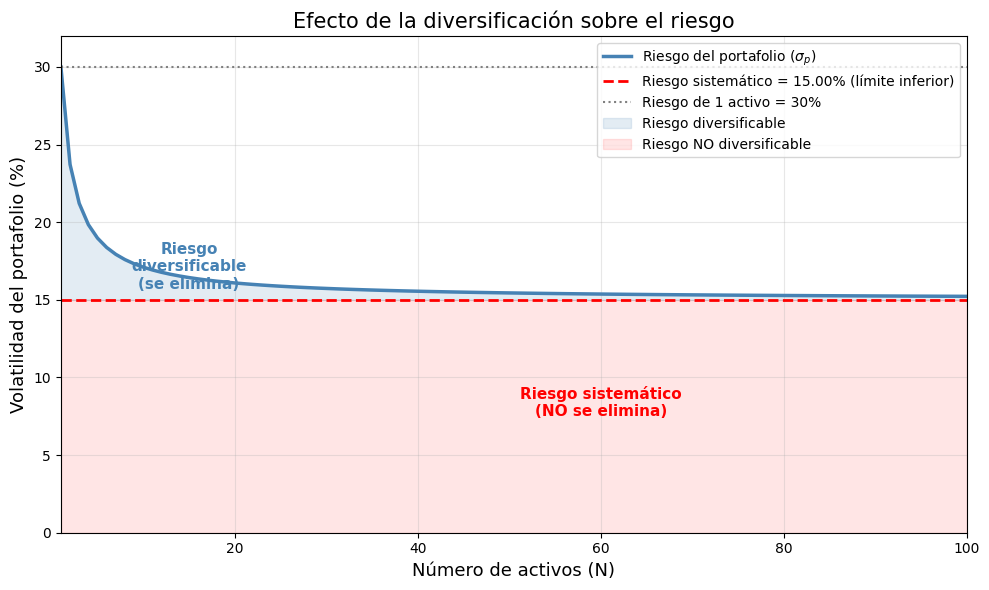

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

# Curva de riesgo del portafolio
ax.plot(N_valores, vol_p * 100, color="steelblue", linewidth=2.5,
        label="Riesgo del portafolio ($\\sigma_p$)")

# Línea asintótica: riesgo sistemático
ax.axhline(y=vol_sistematico * 100, color="red", linestyle="--", linewidth=2,
           label=f"Riesgo sistemático = {vol_sistematico:.2%} (límite inferior)")

# Riesgo de 1 solo activo
ax.axhline(y=sigma * 100, color="gray", linestyle=":", linewidth=1.5,
           label=f"Riesgo de 1 activo = {sigma:.0%}")

# Sombrear la zona de riesgo diversificable
ax.fill_between(N_valores, vol_p * 100, vol_sistematico * 100,
                alpha=0.15, color="steelblue", label="Riesgo diversificable")
ax.fill_between(N_valores, vol_sistematico * 100, 0,
                alpha=0.10, color="red", label="Riesgo NO diversificable")

# Anotaciones
ax.annotate("Riesgo\ndiversificable\n(se elimina)",
            xy=(15, (vol_p[14] * 100 + vol_sistematico * 100) / 2),
            fontsize=11, ha="center", color="steelblue", fontweight="bold")
ax.annotate("Riesgo sistemático\n(NO se elimina)",
            xy=(60, vol_sistematico * 100 / 2),
            fontsize=11, ha="center", color="red", fontweight="bold")

ax.set_xlabel("Número de activos (N)", fontsize=13)
ax.set_ylabel("Volatilidad del portafolio (%)", fontsize=13)
ax.set_title("Efecto de la diversificación sobre el riesgo", fontsize=15)
ax.set_xlim(1, 100)
ax.set_ylim(0, sigma * 100 + 2)
ax.legend(loc="upper right", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Paso 5 — ¿Qué pasa si cambia la correlación?

La correlación $\rho$ determina el **piso** del riesgo. Comparemos diferentes escenarios:

| Correlación | Riesgo mínimo alcanzable | Interpretación |
|---|---|---|
| $\rho = 0$ | $\sigma_p \to 0$ | Sin correlación: el riesgo se elimina por completo |
| $\rho = 0.25$ | $\sigma_p \to 15\%$ | Caso moderado (nuestro ejemplo) |
| $\rho = 0.50$ | $\sigma_p \to 21.2\%$ | Alta correlación: la diversificación ayuda menos |
| $\rho = 1.0$ | $\sigma_p = 30\%$ | Correlación perfecta: diversificar no sirve de nada |

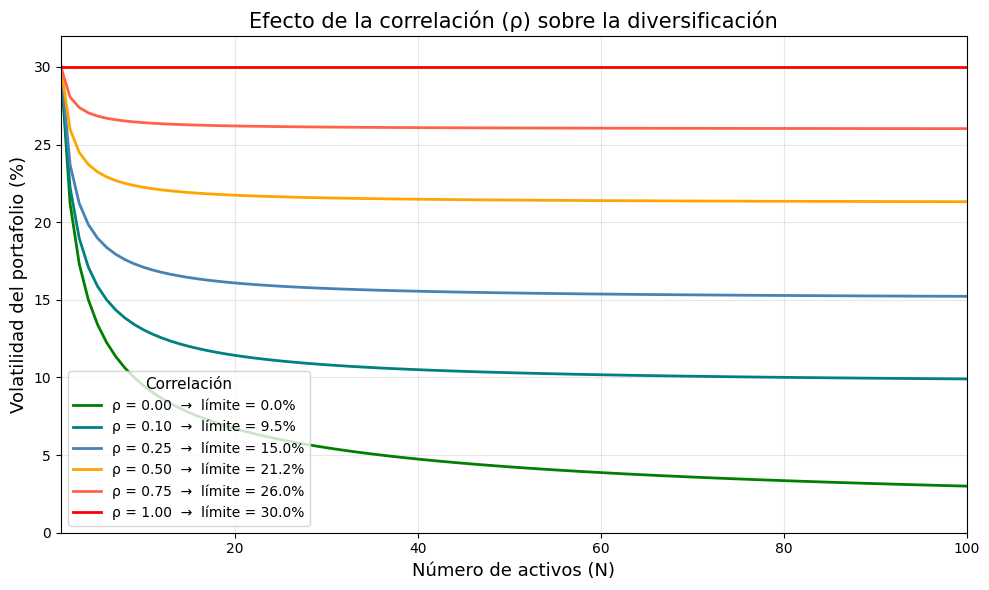

In [6]:
# Comparar diferentes correlaciones
correlaciones = [0.0, 0.10, 0.25, 0.50, 0.75, 1.0]
colores = ["green", "teal", "steelblue", "orange", "tomato", "red"]

fig, ax = plt.subplots(figsize=(10, 6))

for rho_i, color_i in zip(correlaciones, colores):
    vol_i = [np.sqrt(varianza_portafolio(N, sigma, rho_i)) * 100 for N in N_valores]
    limite_i = np.sqrt(rho_i) * sigma * 100
    ax.plot(N_valores, vol_i, linewidth=2, color=color_i,
            label=f"ρ = {rho_i:.2f}  →  límite = {limite_i:.1f}%")

ax.set_xlabel("Número de activos (N)", fontsize=13)
ax.set_ylabel("Volatilidad del portafolio (%)", fontsize=13)
ax.set_title("Efecto de la correlación (ρ) sobre la diversificación", fontsize=15)
ax.set_xlim(1, 100)
ax.set_ylim(0, sigma * 100 + 2)
ax.legend(fontsize=10, title="Correlación", title_fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Paso 6 — Gráfico de descomposición: ¿cuánto riesgo se elimina con cada activo adicional?

Visualicemos el **beneficio marginal** de agregar cada activo adicional. Observa cómo los primeros activos reducen mucho el riesgo, pero a partir de 20-30 activos el beneficio es prácticamente nulo.

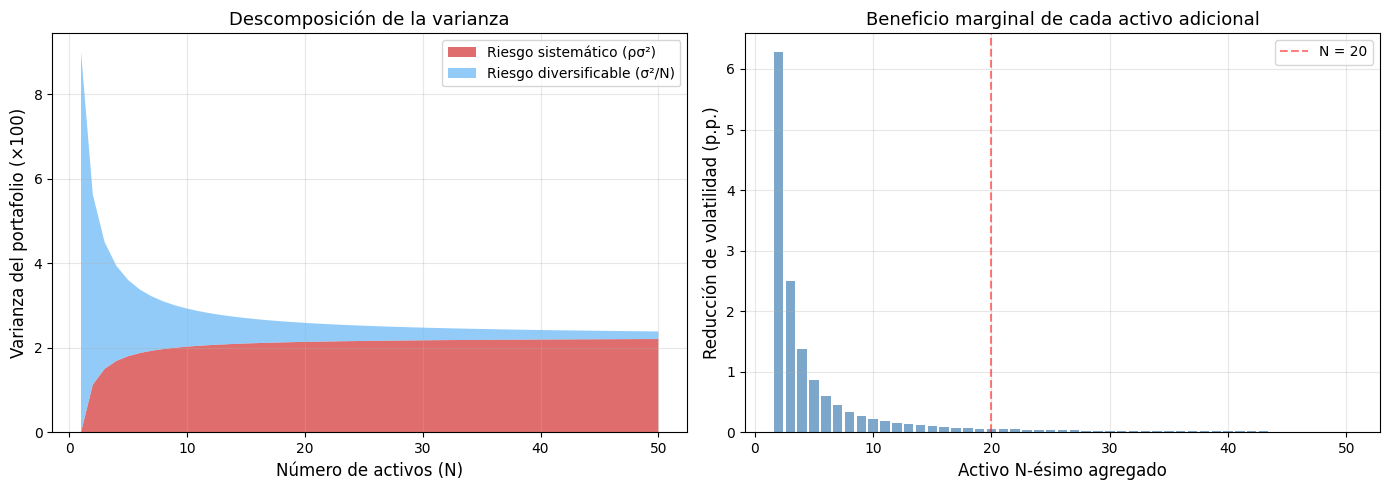

Agregar el 2º activo reduce la volatilidad en 6.28 p.p.
Agregar el 10º activo reduce la volatilidad en 0.22 p.p.
Agregar el 30º activo reduce la volatilidad en 0.02 p.p.
Agregar el 50º activo reduce la volatilidad en 0.01 p.p.


In [5]:
# Descomposición en componentes
N_plot = np.arange(1, 51)
var_ind = sigma**2

comp_diversificable = np.array([var_ind / N for N in N_plot])
comp_sistematico = np.array([(1 - 1/N) * rho * var_ind for N in N_plot])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel izquierdo: componentes de varianza ---
ax1 = axes[0]
ax1.stackplot(N_plot,
              comp_sistematico * 100,
              comp_diversificable * 100,
              labels=["Riesgo sistemático (ρσ²)", "Riesgo diversificable (σ²/N)"],
              colors=["#d32f2f", "#64b5f6"], alpha=0.7)
ax1.set_xlabel("Número de activos (N)", fontsize=12)
ax1.set_ylabel("Varianza del portafolio (×100)", fontsize=12)
ax1.set_title("Descomposición de la varianza", fontsize=13)
ax1.legend(loc="upper right", fontsize=10)
ax1.grid(alpha=0.3)

# --- Panel derecho: reducción marginal ---
ax2 = axes[1]
reduccion_marginal = -np.diff(vol_p[:50]) * 100  # Reducción en puntos porcentuales
ax2.bar(N_plot[1:], reduccion_marginal, color="steelblue", alpha=0.7, width=0.8)
ax2.set_xlabel("Activo N-ésimo agregado", fontsize=12)
ax2.set_ylabel("Reducción de volatilidad (p.p.)", fontsize=12)
ax2.set_title("Beneficio marginal de cada activo adicional", fontsize=13)
ax2.axvline(x=20, color="red", linestyle="--", alpha=0.5, label="N = 20")
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Agregar el 2º activo reduce la volatilidad en {reduccion_marginal[0]:.2f} p.p.")
print(f"Agregar el 10º activo reduce la volatilidad en {reduccion_marginal[8]:.2f} p.p.")
print(f"Agregar el 30º activo reduce la volatilidad en {reduccion_marginal[28]:.2f} p.p.")
print(f"Agregar el 50º activo reduce la volatilidad en {reduccion_marginal[48]:.2f} p.p.")

## Conclusiones

### ¿Por qué el riesgo es asintótico y no llega a cero?

La fórmula lo explica claramente:

$$\sigma^2_p = \underbrace{\frac{\sigma^2}{N}}_{\to \, 0} + \underbrace{\left(1 - \frac{1}{N}\right) \rho \, \sigma^2}_{\to \, \rho \sigma^2}$$

- **El primer término tiende a cero**: al dividir el riesgo individual entre $N$ activos, el riesgo idiosincrático desaparece. Esto es el poder de la diversificación.

- **El segundo término tiende a $\rho \sigma^2$**: la covarianza promedio entre activos NO se reduce al agregar más activos, porque es un riesgo **compartido** por todos (riesgo de mercado, recesiones, tasas de interés, etc.).

### Lecciones clave:

| Hallazgo | Implicación práctica |
|---|---|
| Los primeros 10-20 activos eliminan la mayor parte del riesgo diversificable | No hace falta tener cientos de activos |
| El beneficio marginal cae rápidamente | Agregar el activo 50 casi no aporta reducción |
| El riesgo sistemático ($\rho \sigma^2$) es el piso | Solo se puede reducir con activos de **baja correlación** |
| Si $\rho = 0$, el riesgo teóricamente llega a cero | En la práctica, $\rho > 0$ siempre en mercados reales |

> **En resumen:** La diversificación es una herramienta poderosa pero tiene límites. Reduce el riesgo específico de cada activo, pero **no puede eliminar el riesgo que comparten todos los activos del mercado**.